# 2024 Spoken Wiki attentional word recognition task results

### Analysis is for main diotic experiment
### Models run on all combinations of stimuli
___

In [29]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle
import importlib 
import IPython.display as ipd
%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter

import src.util_process_prolific as up 
importlib.reload(up)


<module 'src.util_process_prolific' from '/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/util_process_prolific.py'>





### Import human data

In [18]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
path_to_expmt_stim = Path("/om/user/imgriff/datasets/human_azim_spotlight_SWC_2024/")
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("azimuth_spotlight_experiment/data/*.json"))

len(human_fnames)

16

## Process Human Results

In [19]:
results_df.itd_passed

0      True
1      True
2      True
3      True
4      True
       ... 
310    True
311    True
312    True
313    True
314    True
Name: itd_passed, Length: 1694, dtype: object

In [31]:
trial_results.condition

26     spatialized
29     catch_trial
32     spatialized
35     spatialized
38     spatialized
          ...     
299    catch_trial
302    spatialized
305    spatialized
308    catch_trial
311    spatialized
Name: condition, Length: 480, dtype: object

In [128]:
## Get all subject data into one df for analysis

dfs = []
for fname in human_fnames:
    try:
        dfs.append(up.get_part_df_swc(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]
results_df = results_df[results_df.itd_passed == True]


## Add snr and condition names as columns - unpack from file code in file names 

# get cond name map
map_path = path_to_expmt_stim / 'human_azim_spotlight_cond_map.pkl' 
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)
stim_cond_map = {f"condition_{k:02}": (v['target_azim'], v['dist_azim_delta']) for k,v in stim_cond_map.items()}

# add as columns 
results_df['condition'], results_df['target_azim'], results_df['dist_azim_delta'] = zip(*results_df['stimulus'].apply(lambda x: up.get_stim_target_azim_and_dist_detla(x, stim_cond_map=stim_cond_map)))

## Add distractor azimuth to results_df 
calc_dist_azim = lambda target_azim, distractor_delta: target_azim + distractor_delta if distractor_delta >= 0 else 360 + distractor_delta
calc_dist_azim = np.vectorize(calc_dist_azim)
results_df['distractor_azim'] = calc_dist_azim(results_df['target_azim'], results_df['dist_azim_delta'])



# # remap azimuths to be in the range -180 to 180 for plotting 
remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 
remap_azim = np.vectorize(remap_azim)
results_df['target_azim'] = remap_azim(results_df['target_azim'])
results_df['distractor_azim'] = remap_azim(results_df['distractor_azim'])
results_df['dist_azim_delta'] = remap_azim(results_df['dist_azim_delta'])


# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str].copy()

# trial_results['condition'] = trial_results['raw_condition'].replace(condition_map)

# screen based on completion 
total_trials = 96
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').condition.count() == total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]
# Add accuracy 
trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')

# add shortened stim name field 
trial_results['stim_name'] = trial_results['stimulus'].str.split('/').str[-1].str.split('.').str[0]

# drop coluns in trial_results that are all nans 
trial_results = trial_results.dropna(axis=1, how='all')

In [129]:
trial_results[['target_azim', 'distractor_azim', 'dist_azim_delta']]

,target_azim,distractor_azim,dist_azim_delta
26,-90.0,30.0,30.0
29,NaN,NaN,NaN
32,0.0,90.0,90.0
35,90.0,60.0,-30.0
38,0.0,0.0,0.0
...,...,...,...
299,NaN,NaN,NaN
302,0.0,-90.0,-90.0
305,0.0,10.0,10.0
308,NaN,NaN,NaN


In [130]:
trial_results = trial_results[trial_results.target_azim != - 90]

In [131]:
# catch_trial_particiapnt_performance
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()

print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 11/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response.isna())]
analysis_df = analysis_df.dropna(axis=1, how='all').dropna(axis=0, how='all')
# analysis_df.groupby('id_subject').condition.count()

N total participants  5
N good participants  4



#### Add re-scored performance based on entries included in excerpt transcripts  

In [132]:
### Make map from cv dictionary ixs to experiment word ixs 

## import cv maps
import pickle
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


## import experiment word map
human_exp_word_key = pickle.load( open(path_to_expmt_stim / "human_azim_spotlight_word_key.pkl", "rb" )) 
exp_word_2_class = {v:k for k,v in human_exp_word_key.items()}



In [133]:
## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifests to trial_results where trial_results.stimulus == manifests.base_str

manifests = pd.read_pickle(path_to_expmt_stim / "human_azim_spotlight_stim_manifest.pdpkl")
# add columns for word int and stim name to map back to participant data 
manifests['word_fname_int'] = manifests['word'].replace(exp_word_2_class)
manifests['stim_name'] = manifests[['gender', 'word_fname_int']].apply(lambda row: f"{row.gender[0]}_{row.word_fname_int:03d}", axis=1)

cols_to_merge = ['stim_name',
                 'word',
                 'target_transcripts',
                 'distractor_transcripts',
                 'distractor_word',

]

analysis_df = pd.merge(analysis_df,
                        manifests[cols_to_merge],
                                    left_on='stim_name', right_on='stim_name', how='left')
analysis_df['confusions'] = (analysis_df.response == analysis_df.distractor_word).astype('int')
analysis_df['accuracy'] = (analysis_df.response == analysis_df.word).astype('int')


# add adjusted accuracy and confusions 
pred_words = analysis_df.response.values
target_words = analysis_df.word.values
target_transcripts = analysis_df.target_transcripts.values
distractor_words = analysis_df.distractor_word.values
distractor_transcripts = analysis_df.distractor_transcripts.values


adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                            if not isinstance(target_transcript, float) else np.nan
                            for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                            ])

adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == dist_word)
                            if not (isinstance(distractor_transcript, float)) else np.nan
                            for pred_word, dist_word, distractor_transcript in zip(pred_words, distractor_words,  distractor_transcripts)
                            ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs

analysis_df = analysis_df[analysis_df.condition != 'catch_trial']


In [134]:
to_check = analysis_df[analysis_df.condition!="catch_trial"]
(to_check.adjusted_accuracy >= to_check.accuracy).all()

True

In [135]:
analysis_df.condition.unique()

array(['spatialized'], dtype=object)

In [136]:
analysis_df.columns

Index(['trial_type', 'trial_index', 'time_elapsed', 'internal_node_id',
       'output_filename', 'id_random', 'id_study', 'id_subject', 'id_session',
       'id_version', 'hc_passed', 'itd_passed', 'rt', 'response', 'stimulus',
       'response_str', 'catch_trial', 'correct_response', 'trial_num',
       'correct', 'n_correct', 'n_incorrect', 'condition', 'target_azim',
       'dist_azim_delta', 'distractor_azim', 'accuracy', 'stim_name', 'word',
       'target_transcripts', 'distractor_transcripts', 'distractor_word',
       'confusions', 'adjusted_accuracy', 'adjusted_confusions'],
      dtype='object')

In [137]:
# get trial data excluding catch trials 


part_summary_df = (analysis_df.groupby(["target_azim", "distractor_azim", 'id_subject'])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())


# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


# add distractor azimuth to dataframe. 


In [138]:
part_summary_df

,target_azim,distractor_azim,id_subject,correct_mean,correct_count,confusions_mean,adjusted_accuracy_mean,adjusted_confusions_mean
0,0.0,-90.0,640175d4fd2062d9fa478050,1.00,2,0.00,1.00,0.00
1,0.0,-90.0,6640d0b7167e1b7765bf4320,0.50,2,0.00,1.00,0.00
2,0.0,-90.0,667981f37ab71596b072c866,1.00,2,0.00,1.00,0.00
3,0.0,-90.0,66899a43c6844e3085106b07,0.50,2,0.00,1.00,0.00
4,0.0,-60.0,640175d4fd2062d9fa478050,0.00,2,0.00,0.50,0.00
...,...,...,...,...,...,...,...,...
75,90.0,80.0,66899a43c6844e3085106b07,0.75,4,0.25,0.75,0.25
76,90.0,90.0,640175d4fd2062d9fa478050,0.25,4,0.00,0.25,0.00
77,90.0,90.0,6640d0b7167e1b7765bf4320,0.50,4,0.00,0.75,0.00
78,90.0,90.0,667981f37ab71596b072c866,0.25,4,0.00,0.25,0.00


### Prelim azimuth plots 

In [141]:
part_summary_df[part_summary_df.target_azim == 90].distractor_azim.unique()

array([ 0., 30., 50., 60., 70., 80., 90.])

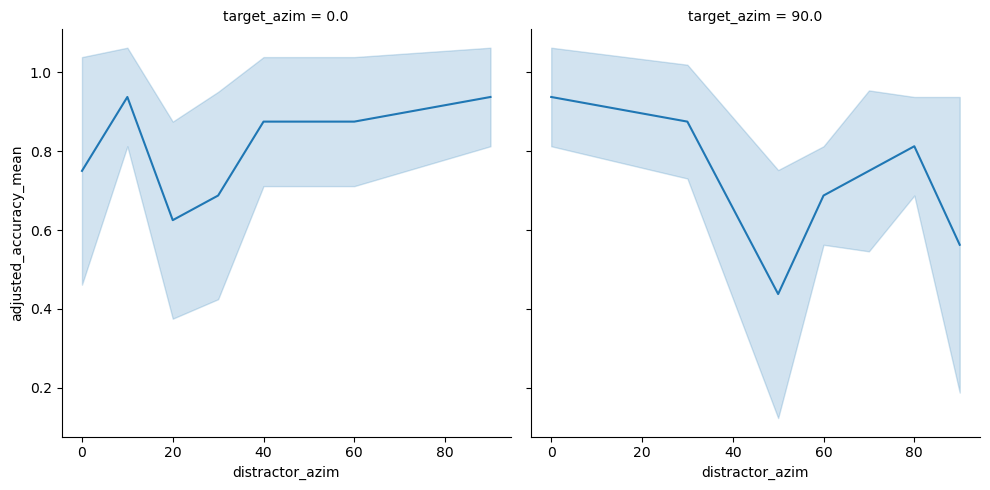

In [144]:
to_plot = part_summary_df.copy()
to_plot['distractor_azim'] = to_plot['distractor_azim'].abs()
sns.relplot(data=to_plot,
            x='distractor_azim',
            y='adjusted_accuracy_mean',
            col='target_azim',
            errorbar=('se', 2),
            kind='line')

In [37]:
# ## Summarize participant data for aggregate plotting

# summary_df = part_summary_df.groupby(['snr', 'condition']).agg({'correct_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count'],
#                                                              'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
# summary_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']
